## **1. Mô tả dữ liệu**

Bộ dữ liệu được **cơ quan an sinh xã hội Mỹ (SSA)** mô tả về tần suất đặt tên cho trẻ sơ sinh từ năm **1880** đến nay

[Datasource name.zip](https://www.google.com/url?sa=D&q=http://www.ssa.gov/oact/babynames/limits.html&ust=1760657760000000&usg=AOvVaw063L9FfdXJnRFNRJ_o5-Os&hl=vi)

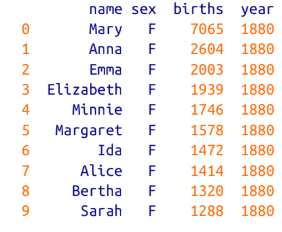

Gồm 4 cột:
- **name**: tên
- **sex**: giới tính (M, F)
- **births**: số lượng trẻ sinh ra có tên đó
- **year**: năm sinh được đặt ở cùng tên file 

## **2. Tìm hiểu dữ liệu**

#### **2.1 Khai báo thư viện**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#### **2.2 Đọc 1 file dữ liệu**

In [2]:
names1880 = pd.read_csv("babynames/yob1880.txt", names=["name", "sex", "births"])
names1880.sort_values("births", ascending=True).head(10)

,name,sex,births
1998,York,M,5
1997,Wright,M,5
1996,Worthy,M,5
1995,Woodie,M,5
1994,Wood,M,5
1993,Winston,M,5
1992,Wes,M,5
1991,Vann,M,5
1990,Unknown,M,5
1989,Tommy,M,5


**Nhận xét:**
- Các tệp này chỉ chứa những cái tên xuất hiện ít nhất năm lần trong mỗi năm.

#### **2.3 Đơn giản hóa bằng việc cho rằng tổng sinh theo giới = tổng sinh của năm đó**

In [3]:
names1880.groupby("sex")["births"].sum()

sex
F     90994
M    110490
Name: births, dtype: int64

#### **2.4 Đọc nhiều files dữ liệu**

In [4]:
pieces = []
for year in range(1880, 2024):
    path = f"babynames/yob{year}.txt"
    frame = pd.read_csv(path, names=["name", "sex", "births"])
    # Add a column for the year
    frame["year"] = year
    pieces.append(frame)
    
# Concatenate everything into a single DataFrame
names = pd.concat(pieces, ignore_index=True)

In [5]:
names.head(10)

,name,sex,births,year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880
5,Margaret,F,1578,1880
6,Ida,F,1472,1880
7,Alice,F,1414,1880
8,Bertha,F,1320,1880
9,Sarah,F,1288,1880


**Nhận xét:**
- `concat` kết hợp các đối tượng DataFrame theo hàng (row) theo mặc định. Nghĩa là các DataFrame sẽ được xếp chồng lên nhau, không phải ghép theo cột.

- `ignore_index=True`: Vì chúng ta không quan tâm giữ nguyên số thứ tự (index) của các hàng khi đọc.

#### **2.5 Tổng sinh hằng năm theo giới tính (Pivot cột giới tính, sum births, index là year)**

In [6]:
total_births = names.pivot_table("births", index="year", columns="sex", aggfunc="sum")
total_births.head(100)

sex,F,M
year,,
1880,90994,110490
1881,91953,100735
1882,107847,113686
1883,112321,104625
1884,129019,114442
...,...,...
1975,1457921,1561473
1976,1465136,1569164
1977,1533173,1643321


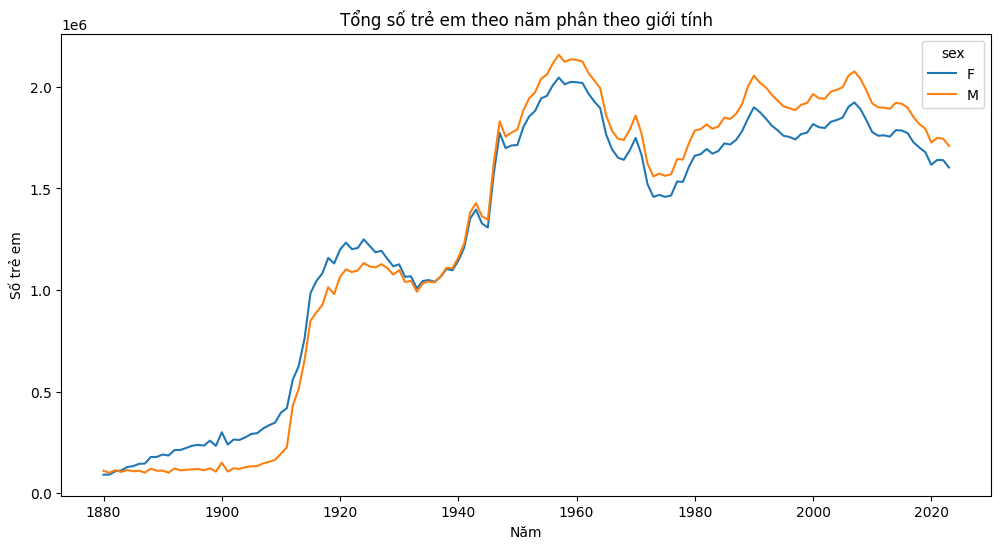

In [7]:
total_births.plot(title="Tổng số trẻ em theo năm phân theo giới tính", figsize=(12,6))
plt.xlabel("Năm")
plt.ylabel("Số trẻ em")
plt.show()

**Nhận xét:**
- Sự chênh lệch về giới tính thấp
- Có sự tăng đột biến vào những năm 1915-1920 và 1940-1960
- Có xu hướng giảm sau năm 2000

#### **2.6 Tỷ lệ tên trên giới tính ở các năm**

In [8]:
names["prop"] = names.groupby(["year", "sex"])["births"].transform(lambda x: x / x.sum())

In [9]:
names.head(1000)

,name,sex,births,year,prop
0,Mary,F,7065,1880,0.077642
1,Anna,F,2604,1880,0.028617
2,Emma,F,2003,1880,0.022012
3,Elizabeth,F,1939,1880,0.021309
4,Minnie,F,1746,1880,0.019188
...,...,...,...,...,...
995,Ralph,M,317,1880,0.002869
996,Ed,M,310,1880,0.002806
997,Claude,M,309,1880,0.002797
998,Edwin,M,309,1880,0.002797


**Nhận xét:**
- Marry có tỷ lệ cao nhất, sấp xỉ 7.7% trên tất cả trẻ giới tính nữ. Vượt xa top 2 khoảng 4.5%
- John và William có tỷ lệ cao nhất, sấp xỉ 8% trên tất cả trẻ giới tính nam

##### `check %`

nếu khác 1 => lỗi

In [10]:
names.groupby(["year", "sex"])["prop"].sum()

year  sex
1880  F      1.0
      M      1.0
1881  F      1.0
      M      1.0
1882  F      1.0
            ... 
2021  M      1.0
2022  F      1.0
      M      1.0
2023  F      1.0
      M      1.0
Name: prop, Length: 288, dtype: float64

#### **2.7 Top 1000 tỷ lên tên trên giới tính theo năm**

In [11]:
def get_top1000(group):
    return group.sort_values("births", ascending=False)[:1000]
grouped = names.groupby(["year", "sex"])
top1000 = grouped.apply(get_top1000)

top1000 = top1000.reset_index(drop=True)
top1000.head()

C:\Users\sonvuuu\AppData\Local\Temp\ipykernel_25604\361822729.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top1000 = grouped.apply(get_top1000)


,name,sex,births,year,prop
0,Mary,F,7065,1880,0.077642
1,Anna,F,2604,1880,0.028617
2,Emma,F,2003,1880,0.022012
3,Elizabeth,F,1939,1880,0.021309
4,Minnie,F,1746,1880,0.019188


## **3. Thống kê xu hướng tên**

#### **3.1 Xu hướng tên của top 1,2 theo giới tính**

**Chia top 1000 theo giới tính**

In [12]:
boys = top1000[top1000["sex"] == "M"]
girls = top1000[top1000["sex"] == "F"]

**Pivot theo tên**

In [13]:
total_births = top1000.pivot_table("births", index="year", columns="name", aggfunc='sum')

In [14]:
total_births.info()

<class 'pandas.core.frame.DataFrame'>
Index: 144 entries, 1880 to 2023
Columns: 7331 entries, Aaden to Zyon
dtypes: float64(7331)
memory usage: 8.1 MB


**Chọn tên**

In [16]:
subset = total_births[["Mary", "Anna", "John", "William"]]

**Biểu đồ**

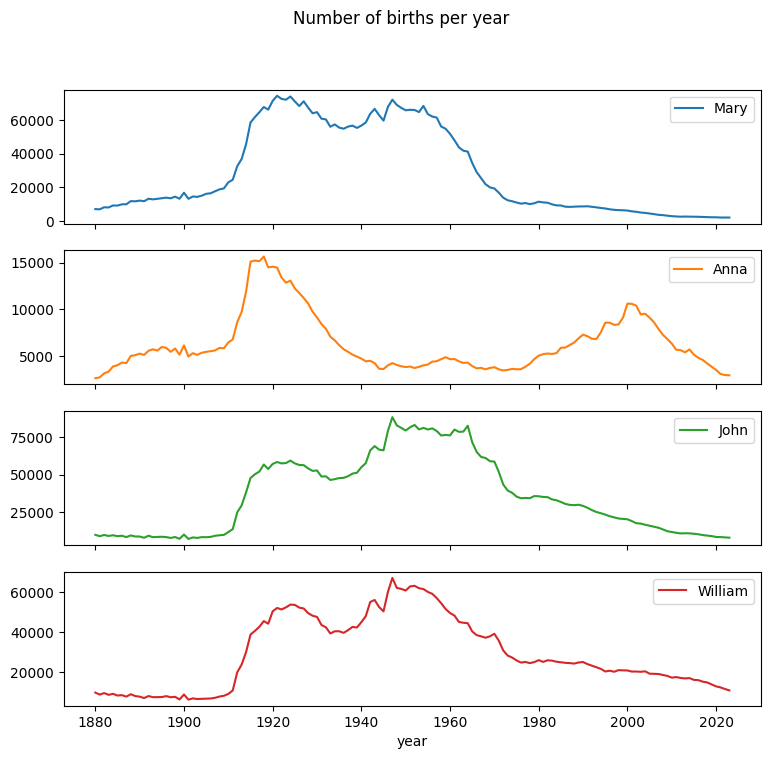

In [17]:
subset.plot(subplots=True, figsize=(9, 8), title="Number of births per year");

**Nhận xét:**
- Mặc dù các tên này được đặt rất nhiều nhưng lại có xu hướng giảm => Tuy nhiều nhưng không còn chiếm sự yêu thích khi đặt tên

#### **3.2 Sự đa dạng về tên đang tăng lên**

##### **3.2.1 Xu hướng top 1000 tên theo năm**

In [18]:
table = top1000.pivot_table("prop", index="year", columns="sex", aggfunc="sum")

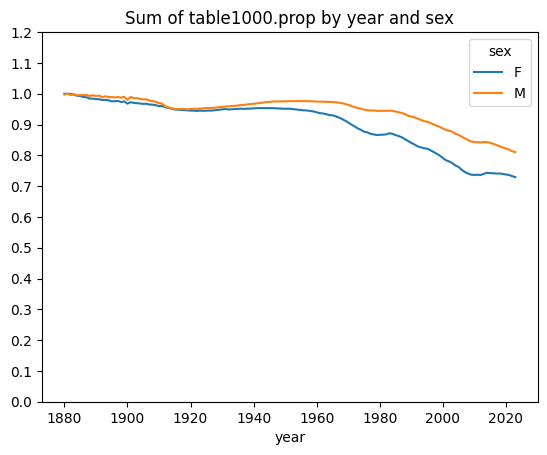

In [19]:
table.plot(title="Sum of table1000.prop by year and sex", yticks=np.linspace(0, 1.2, 13));

**Nhận xét:**
- Xu hướng top 1000 đang suy giảm thể hiện sự yếu đi của những cái tên chiếm thị yếu lớn trong quá khứ

##### **3.2.1 Xu hướng tên năm mới nhất**

In [20]:
df = boys[boys["year"] == 2023]
df

,name,sex,births,year,prop
286876,Liam,M,20886,2023,0.012224
286877,Noah,M,19088,2023,0.011172
286878,Oliver,M,14782,2023,0.008652
286879,James,M,11727,2023,0.006864
286880,Elijah,M,11503,2023,0.006733
...,...,...,...,...,...
287871,Kody,M,222,2023,0.000130
287872,Abner,M,221,2023,0.000129
287873,Harley,M,221,2023,0.000129
287874,Ulises,M,221,2023,0.000129


**Nhận xét:**
- Các tên xu hướng năm 2023 không bao gồm tên chiếm tỷ lệ cao trong top 1000

##### **3.2.2 Xem mức 50% ở năm 1900 và 2023. (demo cumsum và searchsorted (Tứ phân vị))**

##### a. Demo hàm và ý tưởng

**cumsum cộng dồn giá trị lên ví dụ: Jonh 5%, Will 7% giờ cumsum là Jonh 5%, Will 12%.**

**Tìm đến khi nào 50%**

In [21]:
prop_cumsum = df["prop"].sort_values(ascending=False).cumsum()
prop_cumsum[:10]

286876    0.012224
286877    0.023396
286878    0.032048
286879    0.038912
286880    0.045645
286881    0.052246
286882    0.058733
286883    0.065165
286884    0.071534
286885    0.077769
Name: prop, dtype: float64

In [22]:
prop_cumsum.searchsorted(0.5)

np.int64(177)

**177 là vị trí đạt 50%**

`Tên của boys năm 1900`

In [23]:
df = boys[boys.year == 1900]

in1900 = df.sort_values("prop", ascending=False).prop.cumsum()

in1900.searchsorted(0.5) + 1 # +1 vì index đi từ 0. Nếu ko +1 thì nó lấy chưa tới 50%

np.int64(25)

**Nhận xét:**
- 2023 tên đa dạng hơn 1900.
- 2023 có 177 cái tên mới chiếm 50% tổng tên
- 1900 chỉ 25 cái tên đã chiếm 50% tổng tên

##### áp dụng

In [24]:
def get_quantile_count(group, q=0.5):
    group = group.sort_values("prop", ascending=False)
    return group.prop.cumsum().searchsorted(q) + 1
diversity = top1000.groupby(["year", "sex"]).apply(get_quantile_count)
diversity = diversity.unstack()

C:\Users\sonvuuu\AppData\Local\Temp\ipykernel_25604\537457807.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  diversity = top1000.groupby(["year", "sex"]).apply(get_quantile_count)


In [25]:
diversity.head()

sex,F,M
year,,
1880,38,14
1881,38,14
1882,38,15
1883,39,15
1884,39,16


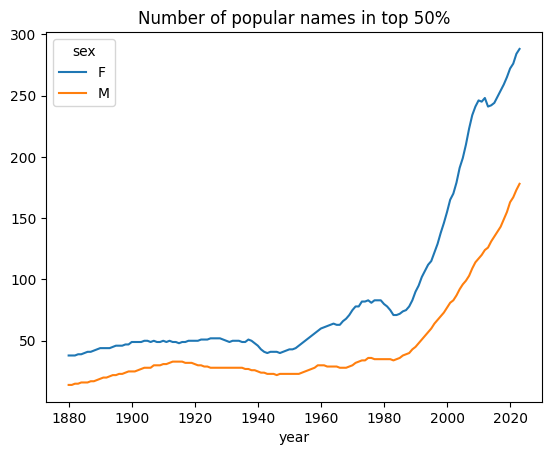

In [26]:
diversity.plot(title="Number of popular names in top 50%");

**Nhận xét:**
- Sự đa dạng trong các tên được đặt tăng mạnh

## **4. Thống kê kí tự cuối cùng**

In [37]:
def get_last_letter(x):
    return x[-1]
last_letters = names["name"].map(get_last_letter)

last_letters.name = "last_letter"
table = names.pivot_table("births", index=last_letters, columns=["sex", "year"], aggfunc="sum")

In [38]:
subtable = table.reindex(columns=[1910, 1960, 2010], level="year")
subtable.head()

sex                 F                            M                    
year             1910      1960      2010     1910      1960      2010
last_letter                                                           
a            108399.0  691254.0  677566.0    977.0    5216.0   28906.0
b                 NaN     694.0     455.0    411.0    3913.0   39320.0
c                 5.0      49.0     958.0    482.0   15456.0   23378.0
d              6751.0    3732.0    2645.0  22111.0  262105.0   44876.0
e            133599.0  435000.0  317138.0  28665.0  178731.0  130395.0

In [39]:
subtable.sum()

sex  year
F    1910     396503.0
     1960    2021900.0
     2010    1777327.0
M    1910     194208.0
     1960    2131915.0
     2010    1918412.0
dtype: float64

`Lấy %`

In [40]:
letter_prop = subtable / subtable.sum()
letter_prop

sex                 F                             M                    
year             1910      1960      2010      1910      1960      2010
last_letter                                                            
a            0.273388  0.341883  0.381228  0.005031  0.002447  0.015068
b                 NaN  0.000343  0.000256  0.002116  0.001835  0.020496
c            0.000013  0.000024  0.000539  0.002482  0.007250  0.012186
d            0.017026  0.001846  0.001488  0.113852  0.122943  0.023392
e            0.336943  0.215144  0.178435  0.147599  0.083836  0.067970
f                 NaN  0.000010  0.000055  0.000783  0.004331  0.001206
g            0.000144  0.000156  0.000376  0.002260  0.009487  0.001407
h            0.051531  0.036222  0.076021  0.045565  0.037912  0.051839
i            0.001526  0.039966  0.031698  0.000844  0.000609  0.022672
j                 NaN       NaN  0.000093       NaN       NaN  0.000774
k            0.000121  0.000155  0.000356  0.036579  0.049366  0.018530
l            0.043188  0.033870  0.026388  0.065023  0.104886  0.070454
m            0.001200  0.008612  0.002602  0.058046  0.033828  0.024706
n            0.079238  0.130675  0.140047  0.143388  0.152521  0.362396
o            0.001672  0.002438  0.001247  0.017064  0.012833  0.042551
p            0.000018  0.000023  0.000020  0.003172  0.005675  0.001268
q                 NaN       NaN  0.000030       NaN       NaN  0.000180
r            0.013395  0.006765  0.018045  0.064472  0.031049  0.087392
s            0.039036  0.012761  0.013339  0.130798  0.102694  0.065160
t            0.027432  0.015196  0.007837  0.072886  0.065645  0.022856
u            0.000683  0.000575  0.000416  0.000124  0.000057  0.001228
v                 NaN  0.000060  0.000117  0.000113  0.000036  0.001450
w            0.000020  0.000031  0.001191  0.006323  0.007704  0.016182
x            0.000015  0.000037  0.000731  0.003965  0.001851  0.008597
y            0.110975  0.152549  0.116747  0.077345  0.161020  0.058210
z            0.002436  0.000658  0.000700  0.000170  0.000183  0.001830

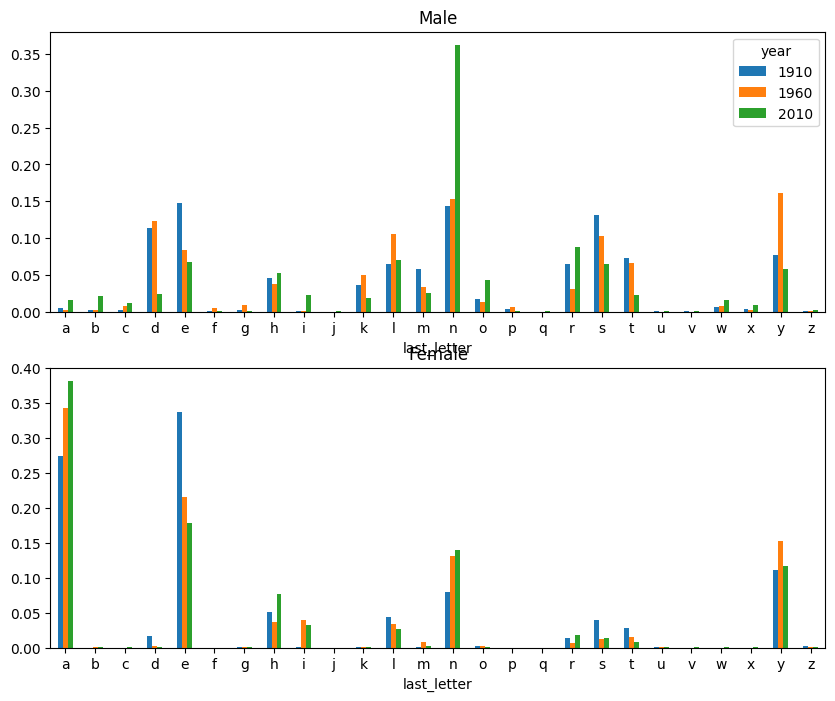

In [41]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
letter_prop["M"].plot(kind="bar", rot=0, ax=axes[0], title="Male")
letter_prop["F"].plot(kind="bar", rot=0, ax=axes[1], title="Female",
legend=False);

**Nhận xét**
- Kí tự a luôn được yêu thích ở cả 3 năm ở giới nữ
- Năm 2010 ở `male` cho thấy sự bùng nổ của những cái tên có kí `n` ở cuối 
- Năm 2010 ở `female` cho thấy sự bùng nổ của những cái tên có kí `a` ở cuối 
- Năm 1910 kí tự `e` chiếm đa số ở cả 2 giới

In [42]:
dny_ts = letter_prop.loc[["d", "n", "y"], "M"].T

In [43]:
dny_ts.head()

last_letter,d,n,y
year,,,
1910,0.113852,0.143388,0.077345
1960,0.122943,0.152521,0.161020
2010,0.023392,0.362396,0.058210


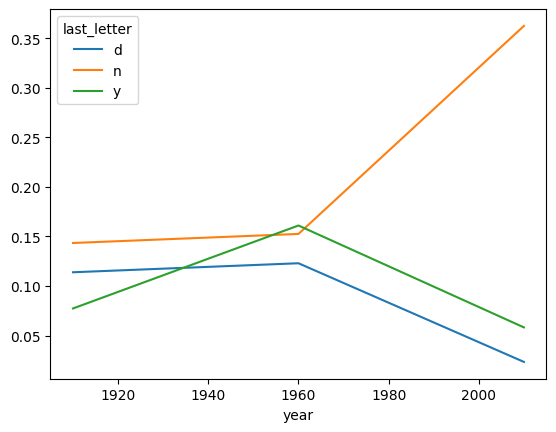

In [44]:
dny_ts.plot();

## **5. Thống kê tên nam được dùng cho nữ (ngược lại)**

In [45]:
all_names = pd.Series(top1000["name"].unique())

In [47]:
lesley_like = all_names[all_names.str.contains("Lesl")]

In [48]:
lesley_like

645     Leslie
2324    Lesley
4238    Leslee
4709     Lesli
6084     Lesly
dtype: object

In [49]:
filtered = top1000[top1000["name"].isin(lesley_like)]

In [50]:
filtered.groupby("name")["births"].sum()

name
Leslee       994
Lesley     35029
Lesli        929
Leslie    380627
Lesly      11434
Name: births, dtype: int64

In [51]:
table = filtered.pivot_table("births", index="year", columns="sex", aggfunc="sum")

In [52]:
table = table.div(table.sum(axis="columns"), axis="index")

In [53]:
table.tail()

sex,F,M
year,,
2019,1.0,NaN
2020,1.0,NaN
2021,1.0,NaN
2022,1.0,NaN
2023,1.0,NaN


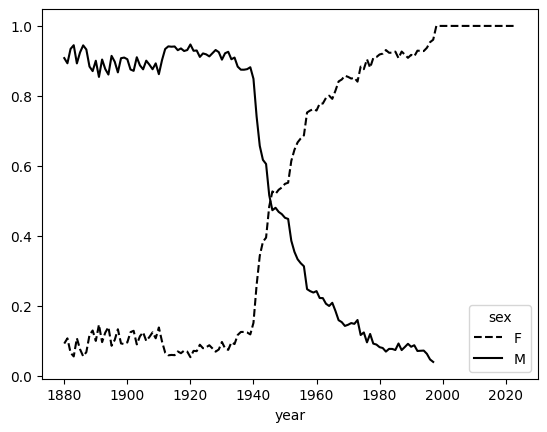

In [54]:
table.plot(style={"M": "k-", "F": "k--"});

**Nhận xét:**
- Tên có chưa `Lesli` ở nam có xu hướng giảm từ năm 1940 trong khi nữ lại tăng mạnh